In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


In [37]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


# ARIMA Models

In [ ]:
arima_models = auto_arima(data["temp"], trace= True, suppress_warnings= True)

# Split Data

In [39]:
x_train = data["temp"][: -168]
x_test = data["temp"][-168: ]
x_train.shape, x_test.shape

((21815,), (168,))

In [40]:
model = ARIMA(x_test, order = (5, 1, 2))
model_fit = model.fit()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressiv

In [ ]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   temp   No. Observations:                  168
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -301.651
Date:                Sun, 08 Dec 2024   AIC                            619.303
Time:                        15:09:47   BIC                            644.246
Sample:                    06-28-2024   HQIC                           629.427
                         - 07-04-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3265      0.091      3.579      0.000       0.148       0.505
ar.L2          0.9286      0.085     10.880      0.000       0.761       1.096
ar.L3         -0.1989      0.165     -1.206      0.228      -0.522       0.124
ar.L4         -0.0948      0.060     -1.587      0.112      -0.212       0.022
ar.L5         -0.2143      0.123     -1.749      0.080      -0.454       0.026
ma.L1          0.0251      0.141      0.178      0.859      -0.252       0.302
ma.L2         -0.9697      0.140     -6.928      0.000      -1.244      -0.695
sigma2         2.1434      0.269      7.956      0.000       1.615       2.671
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):               136.84
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):               1.66   Skew:                            -0.74
Prob(H) (two-sided):                  0.06   Kurtosis:                         7.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### So our ARIMA model will be 

### $X_{t} - 0.327\cdot X_{t-1} - 0.928\cdot X_{t-2} + 0.199\cdot X_{t-3} + 0.095\cdot X_{t-4} + 0.214\cdot X_{t-5} = Z_{t} + 0.025\cdot Z_{t-1} - 0.969\cdot Z_{t-2}$

In [41]:
start_0 = len(x_train)
end_0 = start_0 + len(x_test) - 1
predictions_0 = model_fit.predict(start= start_0, end= end_0, typ='levels')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [42]:
predictions_0.index = x_test.index

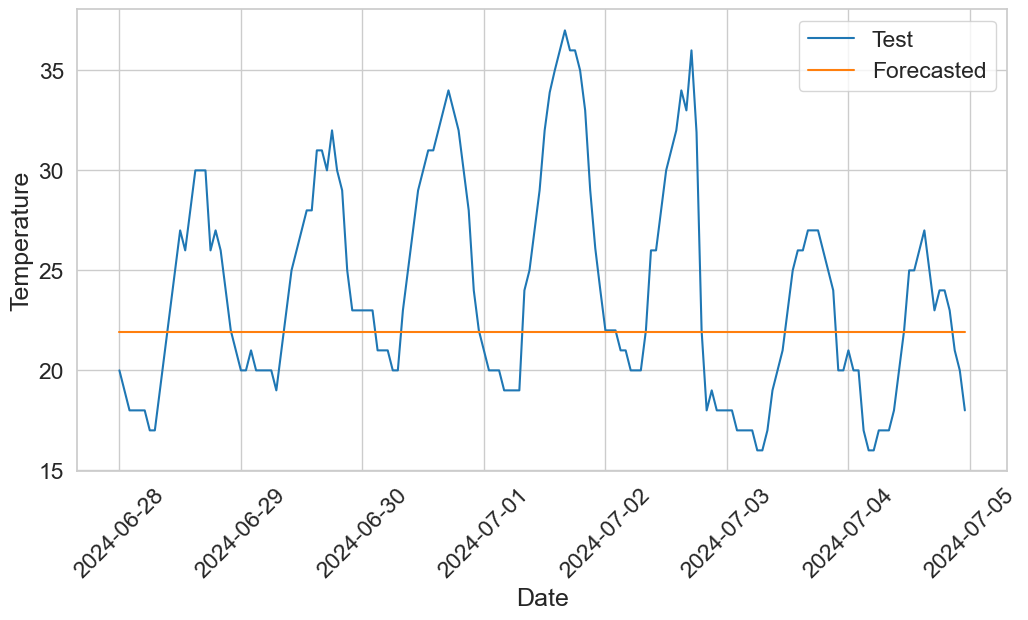

In [43]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
plt.plot(x_test, label='Test')
plt.plot(predictions_0, label='Forecasted')
#plt.title('Actual vs Forecasted Temperature')
plt.xlabel('Date')
plt.xticks(rotation = 45)

plt.ylabel('Temperature')
plt.legend()
plt.show()

### Really bad predictions. But we can see that the Arima model calculated the mean value of the forecasted values very accurately!!

# SARIMA Model

In [44]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(x_train)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -3.4148773501925995
p-value: 0.010462039074684168


In [45]:
model_sarima = SARIMAX(x_train, order=(5, 1, 2), seasonal_order=(1, 1, 1, 24))
model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarni

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           10     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.62691D+00    |proj g|=  2.33272D-01

At iterate    5    f=  1.54266D+00    |proj g|=  4.45264D-02

At iterate   10    f=  1.53261D+00    |proj g|=  2.59956D-03

At iterate   15    f=  1.53250D+00    |proj g|=  1.33737D-02

At iterate   20    f=  1.52337D+00    |proj g|=  1.90679D-02

At iterate   25    f=  1.52197D+00    |proj g|=  5.69035D-03

At iterate   30    f=  1.52193D+00    |proj g|=  2.19505D-04

At iterate   35    f=  1.52193D+00    |proj g|=  3.32099D-04

At iterate   40    f=  1.52191D+00    |proj g|=  6.20586D-04

At iterate   45    f=  1.52187D+00    |proj g|=  3.88832D-03


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f=  1.52175D+00    |proj g|=  3.96793D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   10     50     59      1     0     0   3.968D-03   1.522D+00
  F =   1.5217515830847941     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 
                                      SARIMAX Results                                       
Dep. Variable:                                 temp   No. Observations:                21815
Model:             SARIMAX(5, 1, 2)x(1, 1, [1], 24)   Log Likelihood              -33197.011
Date:                              Sun, 08 Dec 2024   AIC                         

### seasonal_order(1, 1, 1, 24) $\rightarrow$ 65.908%
### seasonal_order(1, 1, 2, 24) $\rightarrow$ 57.995%
### seasonal_order(2, 1, 2, 24) $\rightarrow$ - $\infty%$


In [46]:
x_train.index = pd.to_datetime(x_train.index)
x_test.index = pd.to_datetime(x_test.index)

In [47]:
start = pd.Timestamp('2024-06-28 00:00:00')
end = pd.Timestamp('2024-07-04 23:00:00')

forecast = model_sarima_fit.get_forecast(steps=len(x_test))
predictions = forecast.predicted_mean
predictions.index = x_test.index

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


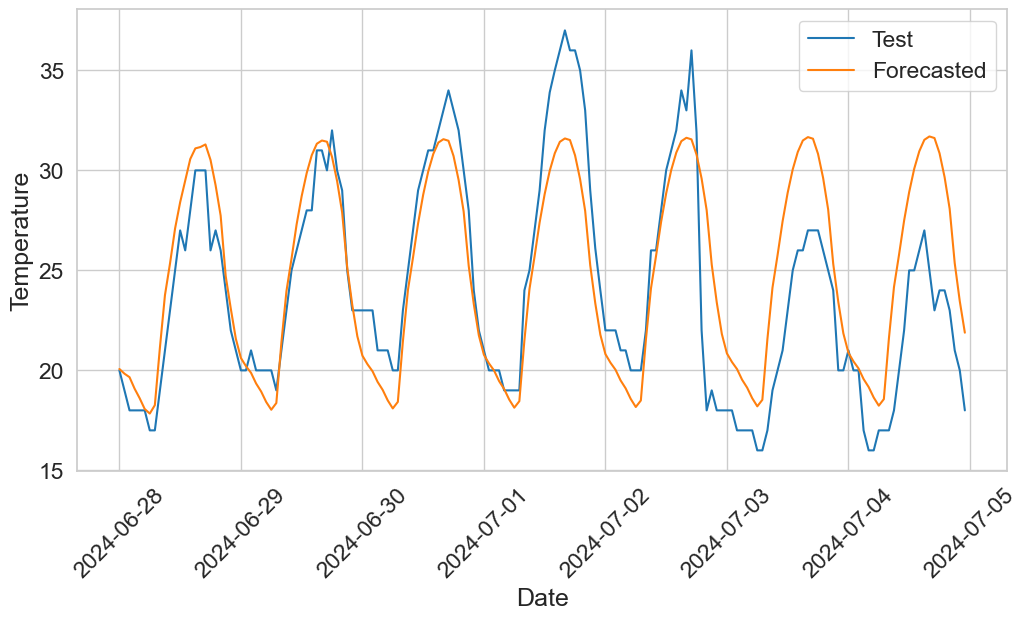

In [48]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
plt.plot(x_test, label='Test')
plt.plot(predictions, label='Forecasted')
#plt.title('Actual vs Forecasted Temperature')
plt.xlabel('Date')
plt.xticks(rotation = 45)

plt.ylabel('Temperature')
plt.legend()
plt.show()

In [33]:
mse = mean_squared_error(x_test, predictions)
tss = ((x_test - x_test.mean()) ** 2).sum()
res = np.sum((x_test - predictions) ** 2)
r_squared = 1 - (res / tss)
print(f" Our model can explain the {round(r_squared, 5)* 100}% of total variability","\n","Root Mean Squared Error = ", np.sqrt(mse))

 Our model can explain the 65.908% of total variability 
 Root Mean Squared Error =  3.11045549053047


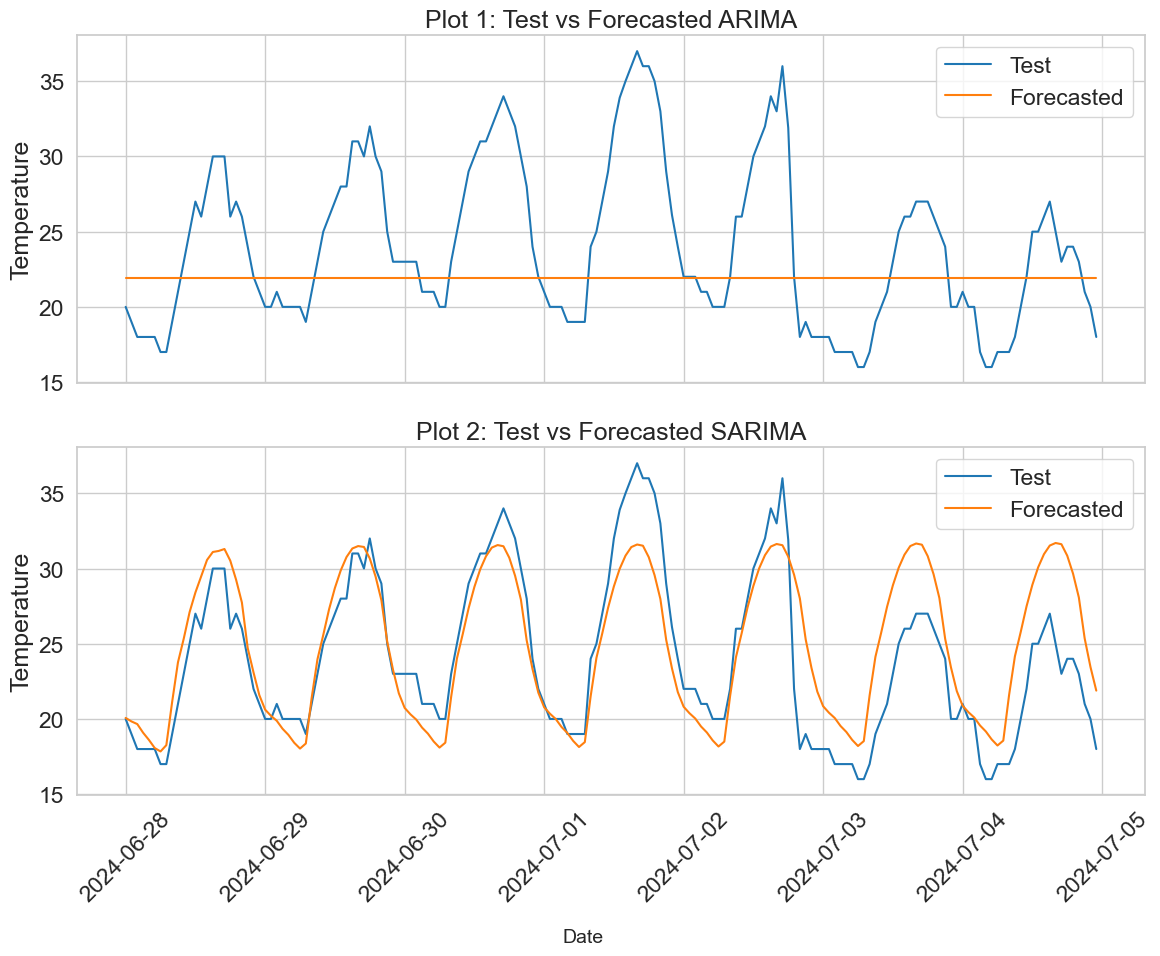

In [ ]:
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")

fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)  

axs[0].plot(x_test, label='Test')
axs[0].plot(predictions_0, label='Forecasted')
axs[0].set_ylabel('Temperature')
axs[0].legend()
axs[0].set_title("Plot 1: Test vs Forecasted ARIMA")

axs[1].plot(x_test, label='Test')
axs[1].plot(predictions, label='Forecasted')
axs[1].set_ylabel('Temperature')
axs[1].legend()
axs[1].set_title("Plot 2: Test vs Forecasted SARIMA")

fig.text(0.5, 0.04, "Date", ha='center', fontsize=14)

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.05, 1, 1])  

plt.show()
